This notebook will calculate the relative contribution of different PVs at different redshifts, to find at what point the PV contributes a negligible fraction to teh total velocity.

In [1]:
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
from matplotlib import cm, colors
from matplotlib.patches import Ellipse
import matplotlib as mpl


from astropy.table import Table, vstack, join
from astropy.coordinates import SkyCoord, Distance
from astropy.cosmology import Planck18, FlatLambdaCDM
from astropy import units as u
from astropy import constants as c
from astropy import constants as const
from astropy.io import fits


from scipy.optimize import brentq
from scipy.spatial.distance import cdist, euclidean

import os

from corner import corner

import pickle


from scipy.stats import binned_statistic

In [2]:
## Define the cosmology
cosmo = FlatLambdaCDM(H0=100, Om0=0.3151)

# Look at lines of constant PV as function of redshift

/tmp/ipykernel_1037308/2328221292.py:11: RuntimeWarning: invalid value encountered in log10
  deltamarray = np.log10(dzarray/dharray)


(0.0, 0.105)

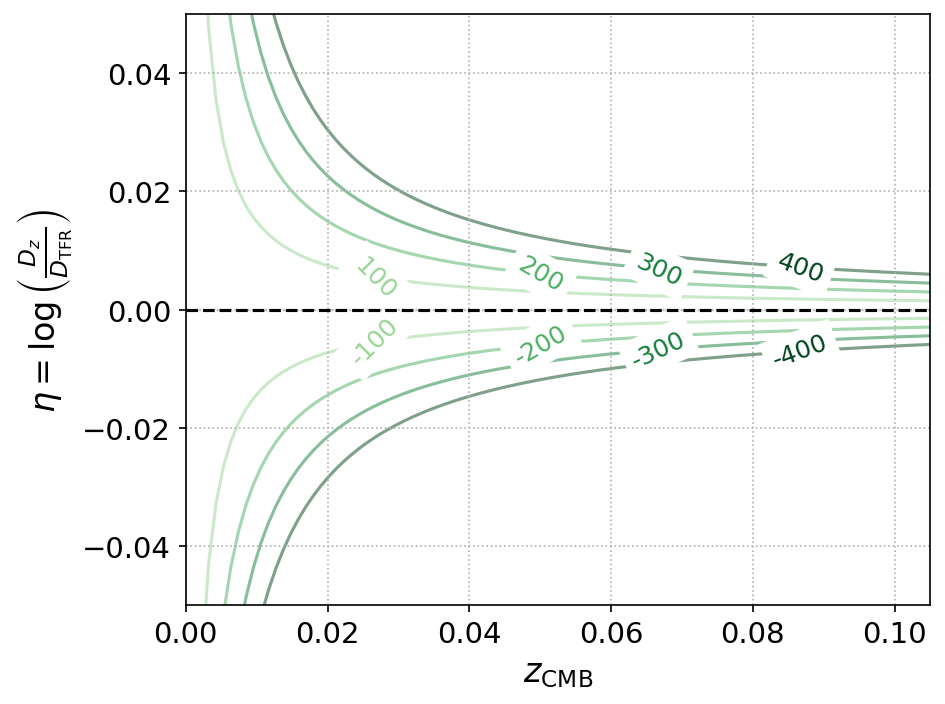

In [9]:
plt.figure(tight_layout=True, dpi=150, facecolor='none')

# PV lines (code taken from Cullen)
c = const.c.to_value('km/s')
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.00005, 0.21, 200)

dzarray = cosmo.comoving_distance(zarray).value
dharray = cosmo.comoving_distance(np.outer(1.0/(1.0 + velarray/c), 
								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/c)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    col = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=col, 
             linestyle='-', 
             alpha=0.5, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/c, ycoord[v], 
                 labels[v], 
                 color=col, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.grid(ls=':')

# plt.vlines([0.03, 0.1], -0.05, 0.05, colors='gray', linestyles='dashed')

plt.tick_params(axis='both',
                which='major', labelsize=14)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=16)
plt.ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', 
           fontsize=16)

plt.ylim((-0.05, 0.05))
# plt.ylim((-0.12, 0.1))
# plt.ylim((-0.2, 0.2))
plt.xlim((0, 0.105))
# plt.xlim((0, 0.2))

# plt.legend(loc='lower right', fontsize=16);

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/TFR_DR2_eta_z_v5a.png',facecolor='none', dpi=150)

# Calculate fractional contribution of PVs at different redshifts

In [4]:
# def fractional_distance_difference(z_obs, v_pv):
#     """
#     Fractional difference between the distance inferred from
#     the observed redshift and the cosmological distance.
#     """

#     z_cos = (1.0 + z_obs) / (1.0 + v_pv/c) - 1.0

#     D_obs = cosmo.comoving_distance(z_obs).value
#     D_cos = cosmo.comoving_distance(z_cos).value

#     return D_obs / D_cos - 1.0


# def z_for_fraction(v_pv, fraction=0.05):
#     """
#     Find the observed redshift at which a peculiar velocity v_pv
#     produces a fractional distance difference of `fraction`.

#     fraction=0.01 -> 1%
#     fraction=0.10 -> 10%
#     """

#     # For positive PV, require z_cos > 0
#     zmin = v_pv / c * (1.0 + 1e-8)

#     f = lambda z: (
#         abs(fractional_distance_difference(z, v_pv)) - fraction
#     )

#     return brentq(f, zmin, 1.0)

In [10]:
def velocity_from_redshift(z):
    """
    Convert a redshift to the corresponding special-relativistic
    recession velocity.

    Returns km/s.
    """
    beta = ((1.0 + z)**2 - 1.0) / ((1.0 + z)**2 + 1.0)
    return beta * c


def z_for_hubble_velocity_fraction(v_pv, fraction=0.95):

    def f(z_obs):

        # Remove the peculiar-velocity contribution using the
        # same redshift composition used in your existing code.
        z_cos = (
            (1.0 + z_obs) / (1.0 + v_pv / c)
            - 1.0
        )

        v_obs = velocity_from_redshift(z_obs)
        v_cos = velocity_from_redshift(z_cos)

        return v_cos / v_obs - fraction

    # Require z_cos > 0 for positive PV
    if v_pv > 0:
        zmin = v_pv / c * (1.0 + 1e-8)
    else:
        zmin = 1e-8

    return brentq(f, zmin, 1.0)


# Make a plot with these values

In [14]:
def plot_hubble_fraction_lines(v_pv, fractions=(0.90, 0.95, 0.99),
                               colors=('tab:blue', 'tab:orange', 'tab:pink'),
                               ymax=0.05):
    """
    Plot vertical lines corresponding to specified fractions of the
    observed velocity being due to the Hubble flow.
    """

    for fraction, color in zip(fractions, colors):

        z = z_for_hubble_velocity_fraction(v_pv, fraction)

        plt.axvline(
            z,
            color=color,
            linestyle='--',
            linewidth=1.5,
            zorder=4,
            # label=f'{v_pv} km/s'
        )
        plt.text(
            z,
            ymax * 0.9,
            f'{100*fraction:.0f}% Hubble flow',
            color=color,
            rotation=90,
            ha='right',
            va='top',
            fontsize=11
        )
    plt.axvline(
            z,
            color=color,
            linestyle='--',
            linewidth=1.5,
            zorder=4,
            label=f'{v_pv} km/s'
        )

/tmp/ipykernel_1037308/1055226585.py:10: RuntimeWarning: invalid value encountered in log10
  deltamarray = np.log10(dzarray/dharray)


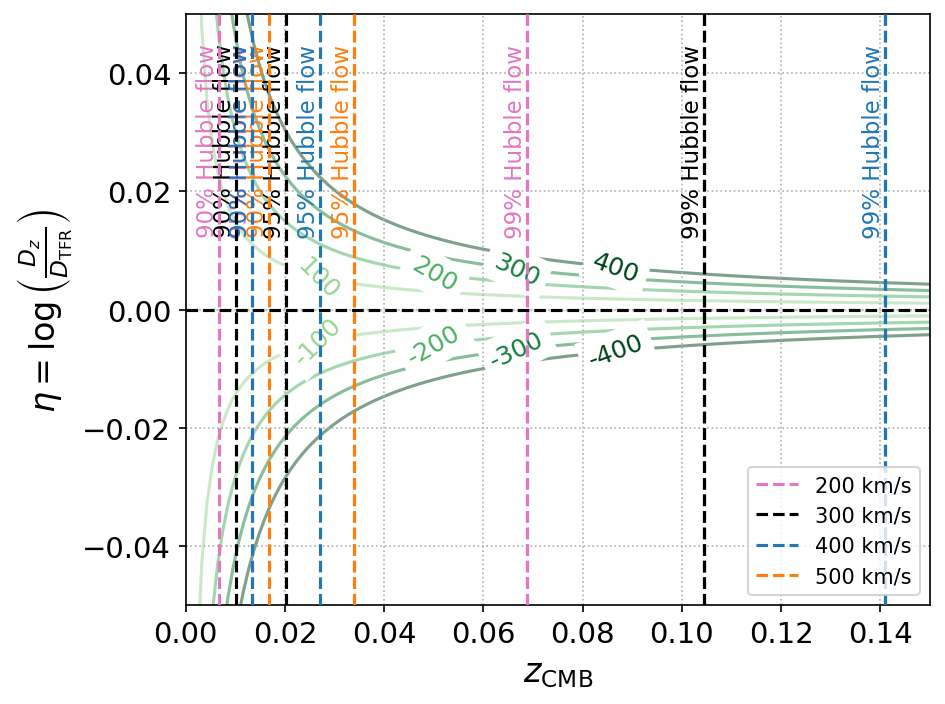

In [16]:
plt.figure(tight_layout=True, dpi=150, facecolor='none')

# PV lines (code taken from Cullen)
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.00005, 0.21, 200)

dzarray = cosmo.comoving_distance(zarray).value
dharray = cosmo.comoving_distance(np.outer(1.0/(1.0 + velarray/c), 
								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/c)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    col = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=col, 
             linestyle='-', 
             alpha=0.5, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/c, ycoord[v], 
                 labels[v], 
                 color=col, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plot_hubble_fraction_lines(200, colors=('tab:pink', 'tab:pink', 'tab:pink'))
plot_hubble_fraction_lines(300, colors=('k', 'k', 'k'))
plot_hubble_fraction_lines(400, colors=('tab:blue', 'tab:blue', 'tab:blue'))
plot_hubble_fraction_lines(500, colors=('tab:orange', 'tab:orange'))

plt.grid(ls=':')

# plt.vlines([0.03, 0.1], -0.05, 0.05, colors='gray', linestyles='dashed')

plt.tick_params(axis='both',
                which='major', labelsize=14)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=16)
plt.ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', 
           fontsize=16)

plt.ylim((-0.05, 0.05))
# plt.ylim((-0.12, 0.1))
# plt.ylim((-0.2, 0.2))
plt.xlim((0, 0.15))
# plt.xlim((0, 0.2))

plt.legend(loc='lower right');

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/TFR_DR2_eta_z_v5a.png',facecolor='none', dpi=150)

In [20]:
for i in [100,200,300,400,500]:
    print(f'{i} km/s: 95% at z={z_for_hubble_velocity_fraction(i, 0.95):.4f}')

100 km/s: 95% at z=0.0067
200 km/s: 95% at z=0.0134
300 km/s: 95% at z=0.0202
400 km/s: 95% at z=0.0270
500 km/s: 95% at z=0.0339
